# Timing & Bottleneck Analysis — PlanningOrchestrator

Visualiseert de tijdsbesteding **per request** op basis van `phase_timings.json` en `routing_trace.json` artifacts.

**Grafieken:**
1. Waterfall (Gantt) — alle fasen op tijdlijn per request
2. Stacked bar — tijdsopbouw plan / execute / synthesis
3. Token breakdown per fase
4. LLM-turns & tool calls per stap
5. Bottleneck scatter — welke fase domineert?

In [11]:
import json
import os
import tempfile
from datetime import datetime, timezone

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mlflow
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('imports ok')

imports ok


In [12]:
# ── Config ────────────────────────────────────────────────────────────────────
TRACKING_URI = 'sqlite:///C:/Users/AALB/Desktop/mp/graph/graphxmaf/mlflow.db'
EXPERIMENT   = 'graphxmaf-eval'

# Versie(s) die je wilt analyseren — laat leeg voor alle versies
# VERSIONS_FILTER = ['v1-planner-more-data']   # bv. ['baseline', 'v1']
VERSIONS_FILTER = ['v1-simpler-planner-3']   # bv. ['baseline', 'v1']
# VERSION = "v1-simpler-planner-3" 

# Kleuren per fase
PHASE_COLORS = {
    'plan':      '#6366f1',   # indigo
    'synthesis': '#8b5cf6',   # violet
}
AGENT_COLORS = {
    'graph':      '#3b82f6',
    'salesforce': '#10b981',
    'smartsales': '#f59e0b',
    'unknown':    '#9ca3af',
}

mlflow.set_tracking_uri(TRACKING_URI)
print('config ok')

config ok


In [13]:
# ── Data laden: child-runs + artifacts ───────────────────────────────────────
exp = mlflow.get_experiment_by_name(EXPERIMENT)
if exp is None:
    raise RuntimeError(f'Experiment "{EXPERIMENT}" niet gevonden.')

client = mlflow.tracking.MlflowClient()

# MLflow ondersteunt geen AND + OR in één filter — alles ophalen, in Python filteren.
raw = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string='tags.mlflow.parentRunId != ""',
    output_format='pandas',
)

# Versie-filter in Python
if VERSIONS_FILTER and 'tags.version' in raw.columns:
    raw = raw[raw['tags.version'].isin(VERSIONS_FILTER)]

print(f'Gevonden: {len(raw)} child-runs  (versies: {raw["tags.version"].unique().tolist() if "tags.version" in raw.columns else "n/a"})')

def _load_json_artifact(run_id: str, suffix: str) -> dict | None:
    """Laad een artifact op basis van naam-suffix (temp-file namen vanuit mlflow_eval)."""
    try:
        arts = client.list_artifacts(run_id)
        match = next((a for a in arts if suffix in a.path), None)
        if match is None:
            return None
        tmp = client.download_artifacts(run_id, match.path, tempfile.gettempdir())
        with open(tmp, encoding='utf-8') as f:
            return json.load(f)
    except Exception:
        return None

records = []
for _, row in raw.iterrows():
    run_id   = row['run_id']
    run_name = row.get('tags.mlflow.runName', run_id[:8])
    version  = row.get('tags.version', '')
    category = row.get('tags.category', '')
    diff     = row.get('tags.difficulty', '')
    query    = row.get('params.query', '')

    pt = _load_json_artifact(run_id, 'phase_timings')
    rt = _load_json_artifact(run_id, 'routing_trace')

    if pt is None:
        continue

    plan_lat   = pt.get('plan',      {}).get('latency_s', 0)
    synth_lat  = pt.get('synthesis', {}).get('latency_s', 0)
    steps_data = pt.get('steps', [])
    plan_tok   = pt.get('plan',      {})
    synth_tok  = pt.get('synthesis', {})

    # Bouw waves vanuit plan (depends_on) voor parallelle tijdlijn
    plan_steps = (rt or {}).get('plan', {}).get('steps', []) if rt else []

    completed = set()
    waves = []
    remaining = list(plan_steps)
    while remaining:
        wave = [s for s in remaining if all(d in completed for d in s.get('depends_on', []))]
        if not wave:
            break
        waves.append(wave)
        for s in wave:
            completed.add(s['id'])
        remaining = [s for s in remaining if s not in wave]

    # Als er geen plan_steps in routing_trace zijn (oudere runs), val terug op steps_data volgorde
    if not waves and steps_data:
        waves = [[{'id': s['step_id'], 'agent': s.get('agent', 'unknown'), 'depends_on': []}]
                 for s in steps_data]

    pt_by_id = {s['step_id']: s for s in steps_data}

    # Tijdlijn opbouwen
    t = 0
    segments = []
    segments.append({'label': 'plan', 'start': t, 'end': t + plan_lat,
                     'color': PHASE_COLORS['plan'], 'tokens': plan_tok,
                     'llm_turns': 1, 'tool_calls': []})
    t += plan_lat

    for wave in waves:
        wave_lat = max((pt_by_id.get(s['id'], {}).get('latency_s', 0) for s in wave), default=0)
        for s in wave:
            sd    = pt_by_id.get(s['id'], {})
            lat   = sd.get('latency_s', 0)
            agent = s.get('agent', 'unknown')
            segments.append({
                'label':       f"step {s['id']}\n{agent}",
                'start':       t,
                'end':         t + lat,
                'color':       AGENT_COLORS.get(agent, AGENT_COLORS['unknown']),
                'tokens':      sd,
                'llm_turns':   sd.get('llm_turns', 0),
                'tool_calls':  sd.get('tool_calls', []),
                'n_tool_calls': sd.get('n_tool_calls', 0),
                'agent':       agent,
                'step_id':     s['id'],
            })
        t += wave_lat

    segments.append({'label': 'synthesis', 'start': t, 'end': t + synth_lat,
                     'color': PHASE_COLORS['synthesis'], 'tokens': synth_tok,
                     'llm_turns': 1, 'tool_calls': []})

    total_execute = sum(s.get('latency_s', 0) for s in steps_data)

    records.append({
        'run_id':          run_id,
        'run_name':        run_name,
        'version':         version,
        'category':        category,
        'difficulty':      diff,
        'query':           str(query)[:80],
        'segments':        segments,
        'plan_lat':        plan_lat,
        'execute_lat':     total_execute,
        'synth_lat':       synth_lat,
        'total_lat':       plan_lat + total_execute + synth_lat,
        'plan_tokens':     plan_tok.get('total_tokens', 0),
        'execute_tokens':  sum(s.get('total_tokens', 0) for s in steps_data),
        'synth_tokens':    synth_tok.get('total_tokens', 0),
        'n_steps':         len(steps_data),
        'total_llm_turns': sum(s.get('llm_turns', 0) for s in steps_data),
        'total_tool_calls': sum(s.get('n_tool_calls', 0) for s in steps_data),
        'llm_score':       row.get('metrics.llm_score'),
        'routing_score':   row.get('metrics.routing_score'),
    })

df = pd.DataFrame(records)
print(f'Records met timing data: {len(df)}')
if len(df):
    display(df[['run_name','category','difficulty','plan_lat','execute_lat','synth_lat','total_lat',
                'n_steps','total_tool_calls','total_llm_turns']].round(2))


Gevonden: 75 child-runs  (versies: ['v1-simpler-planner-3'])


Records met timing data: 9


,run_name,category,difficulty,plan_lat,execute_lat,synth_lat,total_lat,n_steps,total_tool_calls,total_llm_turns
0,tc01_cross-system_hard,cross-system,hard,3.55,36.90,2.12,42.57,2,0,0
1,tc00_cross-system_hard,cross-system,hard,4.97,61.27,6.47,72.72,3,0,0
2,tc08_cross-system_hard,cross-system,hard,4.26,17.48,15.75,37.49,3,0,0
3,tc07_cross-system_hard,cross-system,hard,3.97,27.67,4.30,35.94,2,0,0
4,tc06_cross-system_hard,cross-system,hard,4.05,9.92,2.10,16.08,3,0,0
5,tc05_cross-system_hard,cross-system,hard,3.34,11.97,4.72,20.03,2,0,0
6,tc03_cross-system_hard,cross-system,hard,3.43,15.45,3.06,21.94,2,0,0
7,tc02_cross-system_hard,cross-system,hard,3.21,29.08,4.91,37.20,2,0,0
8,tc01_cross-system_hard,cross-system,hard,3.38,9.25,2.85,15.47,2,0,0


## 1. Waterfall (Gantt) — tijdlijn per request
Elke rij = één request. Elke balk = één fase (plan / stap / synthesis) op absolute tijdlijn.

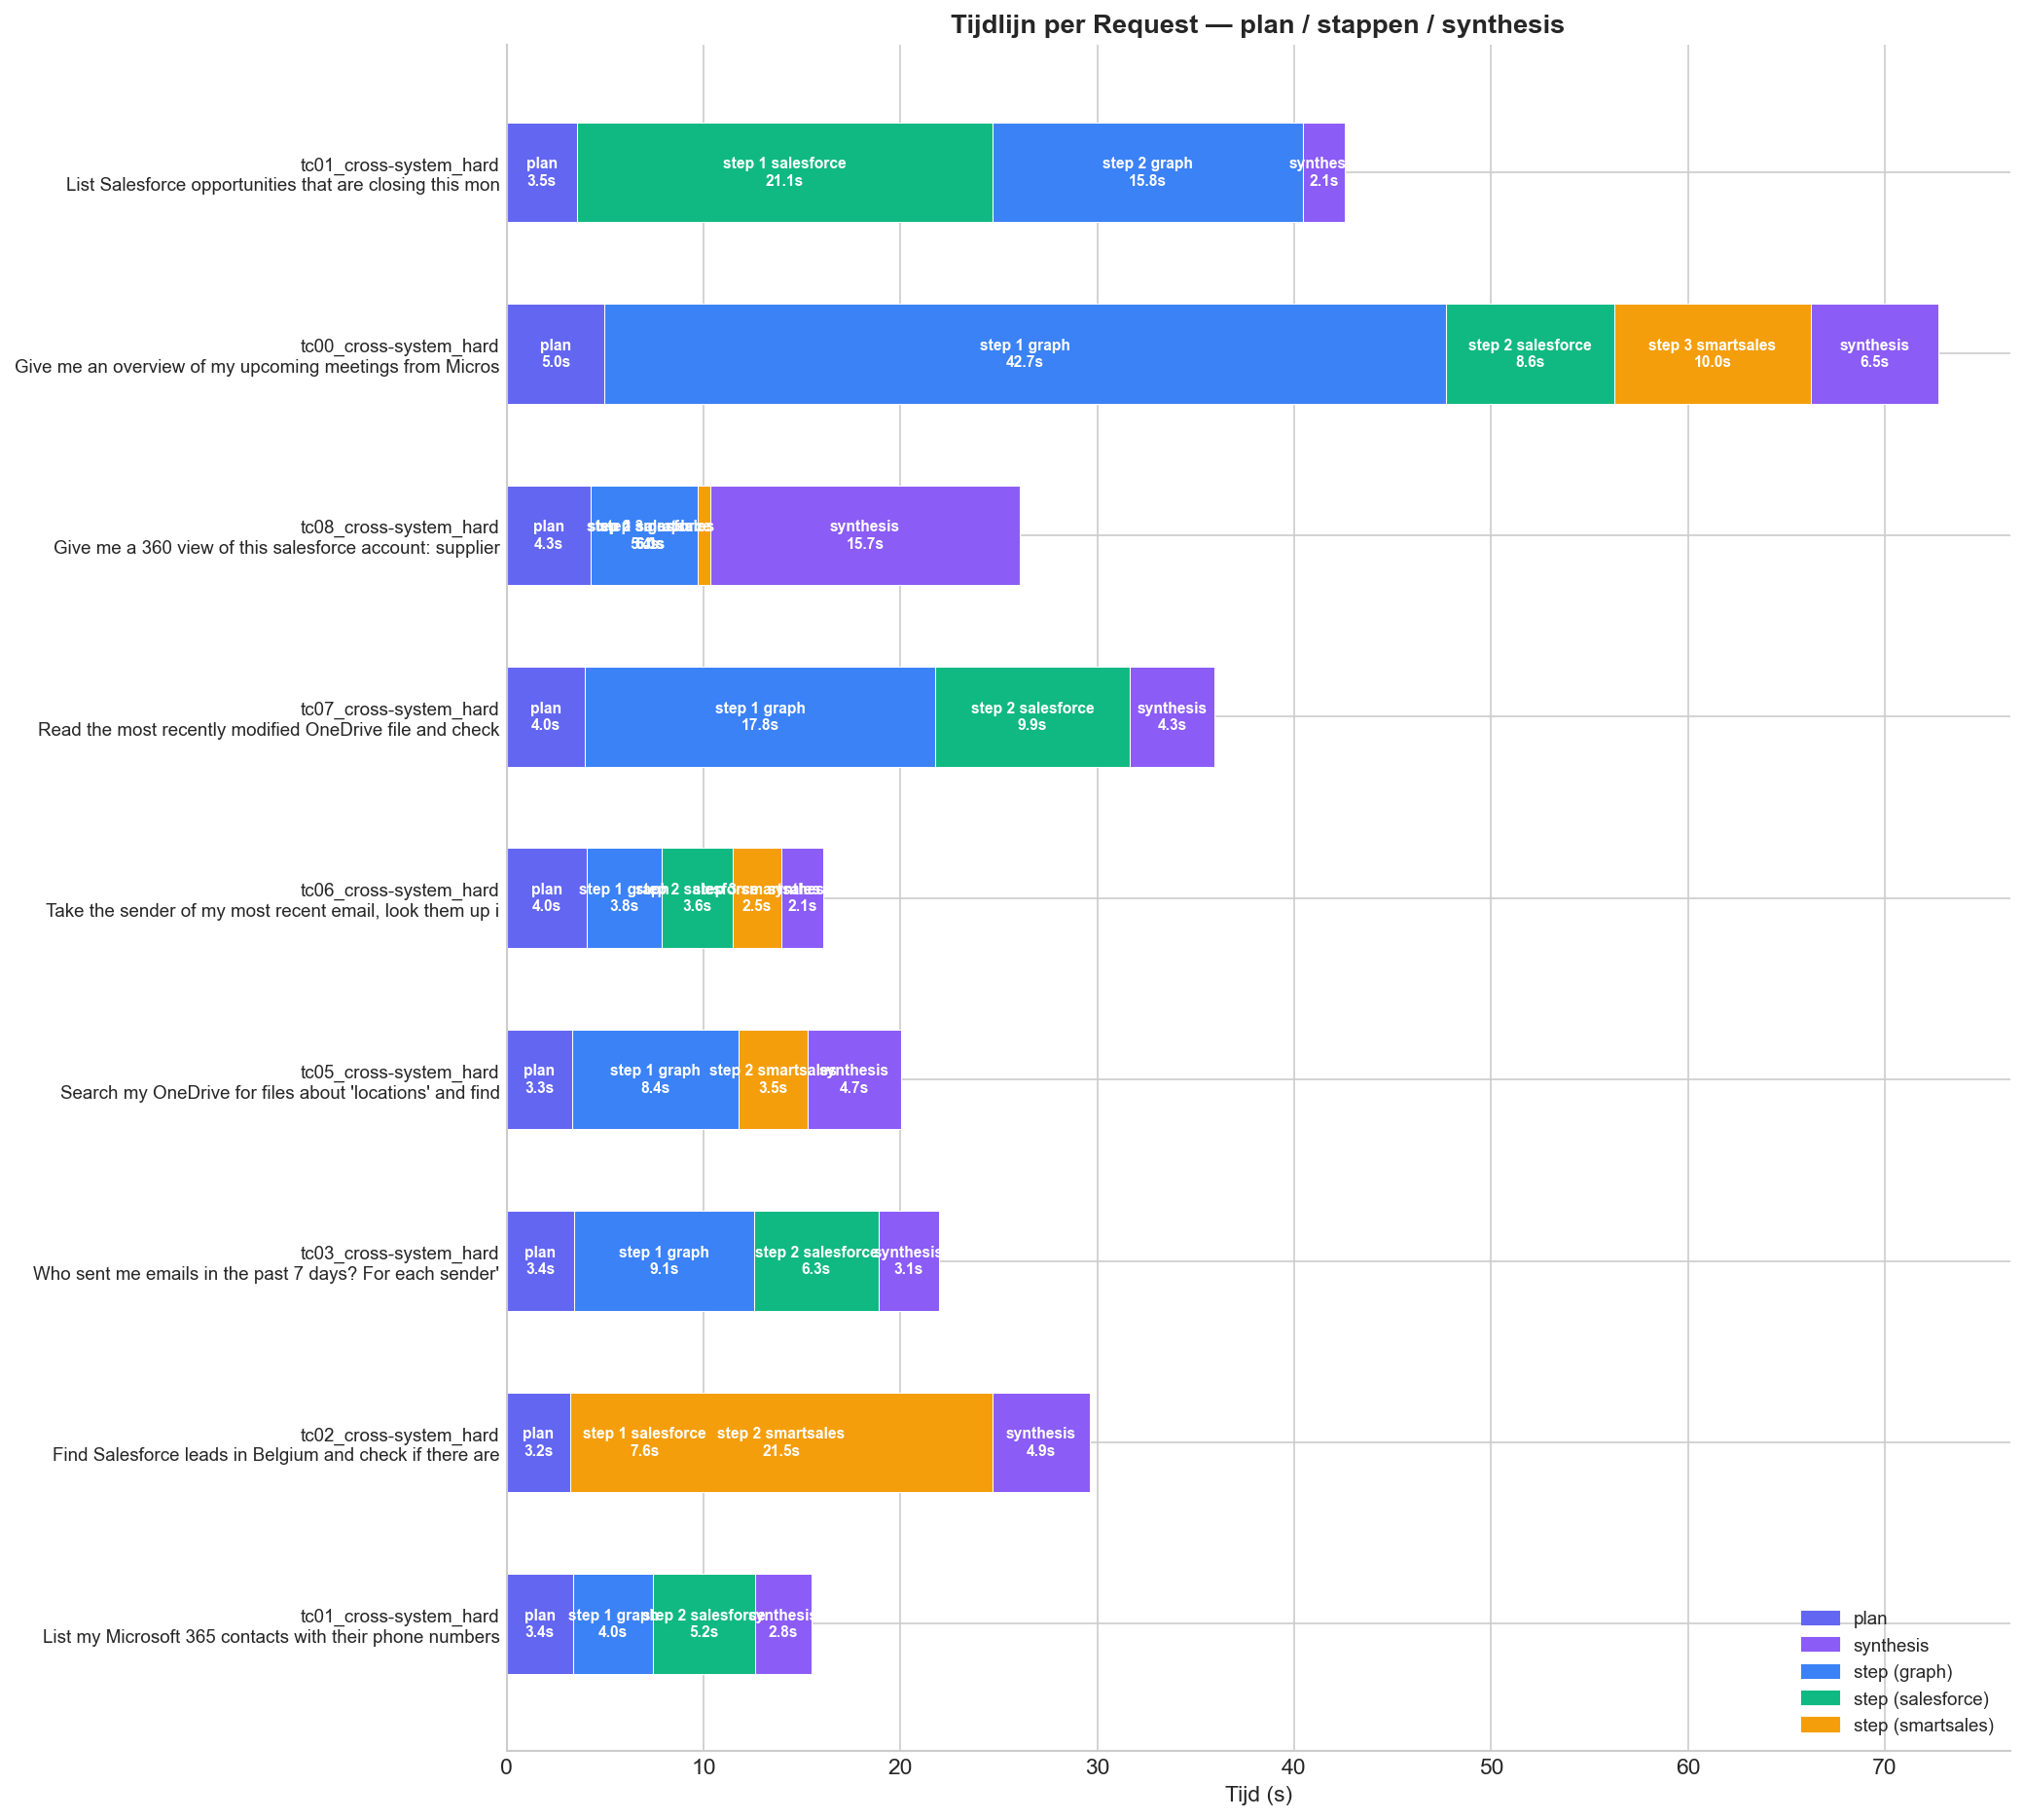

In [14]:
if df.empty:
    print('Geen data.')
else:
    n = len(df)
    fig, ax = plt.subplots(figsize=(14, max(3, n * 1.4)))

    bar_h  = 0.55
    y_ticks, y_labels = [], []

    for i, row in df.iterrows():
        y = n - 1 - list(df.index).index(i)   # bovenste rij = eerste request
        y_ticks.append(y)
        label = f"{row['run_name']}\n{row['query'][:55]}"
        y_labels.append(label)

        for seg in row['segments']:
            width = seg['end'] - seg['start']
            ax.barh(y, width, left=seg['start'], height=bar_h,
                    color=seg['color'], edgecolor='white', linewidth=0.5)
            if width > 0.5:   # label alleen als breed genoeg
                short = seg['label'].replace('\n', ' ')
                ax.text(seg['start'] + width / 2, y, f"{short}\n{width:.1f}s",
                        ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel('Tijd (s)')
    ax.set_title('Tijdlijn per Request — plan / stappen / synthesis', fontweight='bold')

    # Legenda
    legend_patches = [
        mpatches.Patch(color=PHASE_COLORS['plan'],      label='plan'),
        mpatches.Patch(color=PHASE_COLORS['synthesis'], label='synthesis'),
    ]
    for agent, col in AGENT_COLORS.items():
        if agent != 'unknown':
            legend_patches.append(mpatches.Patch(color=col, label=f'step ({agent})'))
    ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig('plot_timing_waterfall.png', bbox_inches='tight')
    plt.show()

## 2. Stacked bar — tijdsopbouw plan / execute / synthesis
Toont voor elke request hoeveel tijd elk onderdeel inneemt als percentage én absoluut.

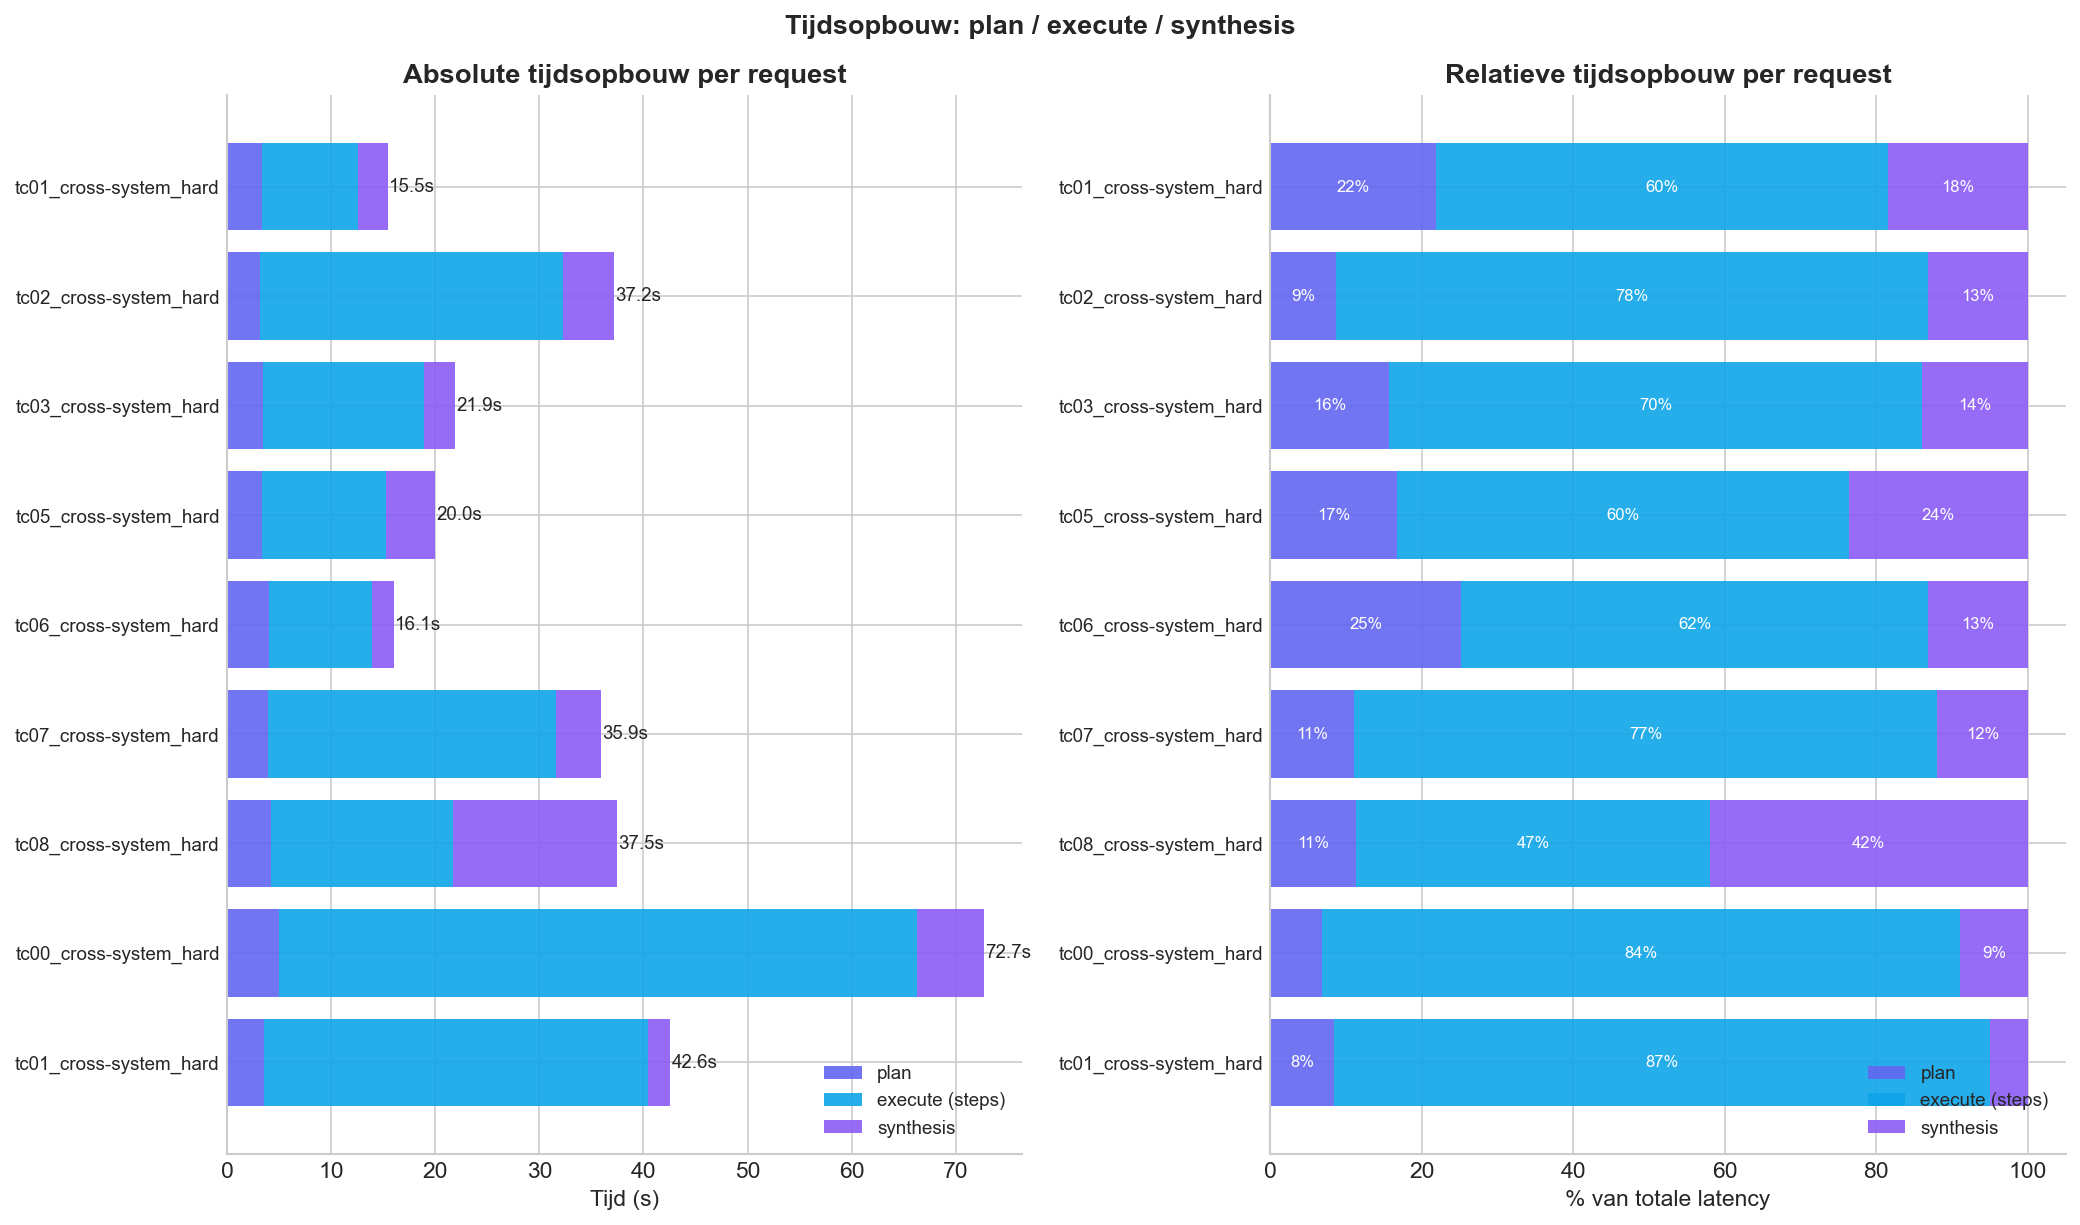


── Gemiddelden ──
  plan        : 3.80s  (14%)
  execute     : 24.33s  (69%)
  synthesis   : 5.14s  (17%)
  totaal      : 33.27s


In [15]:
if df.empty:
    print('Geen data.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(df) * 0.7 + 2)))

    labels = [f"{r['run_name']}" for _, r in df.iterrows()]
    x      = np.arange(len(df))

    plan_v    = df['plan_lat'].values
    execute_v = df['execute_lat'].values
    synth_v   = df['synth_lat'].values
    total_v   = plan_v + execute_v + synth_v

    # -- Absolute tijden (horizontale stacked bar) --
    ax = axes[0]
    b1 = ax.barh(x, plan_v,    color=PHASE_COLORS['plan'],      label='plan',      alpha=0.9)
    b2 = ax.barh(x, execute_v, left=plan_v,
                 color='#0ea5e9', label='execute (steps)', alpha=0.9)
    b3 = ax.barh(x, synth_v,   left=plan_v + execute_v,
                 color=PHASE_COLORS['synthesis'], label='synthesis', alpha=0.9)

    # totaal-label aan het einde van elke balk
    for i, tot in enumerate(total_v):
        ax.text(tot + 0.1, i, f'{tot:.1f}s', va='center', fontsize=9)

    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Tijd (s)')
    ax.set_title('Absolute tijdsopbouw per request', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

    # -- Percentage (genormaliseerd) --
    ax = axes[1]
    plan_pct    = plan_v    / total_v * 100
    execute_pct = execute_v / total_v * 100
    synth_pct   = synth_v   / total_v * 100

    ax.barh(x, plan_pct,    color=PHASE_COLORS['plan'],      label='plan',      alpha=0.9)
    ax.barh(x, execute_pct, left=plan_pct,
            color='#0ea5e9', label='execute (steps)', alpha=0.9)
    ax.barh(x, synth_pct,   left=plan_pct + execute_pct,
            color=PHASE_COLORS['synthesis'], label='synthesis', alpha=0.9)

    for i, (pp, ep, sp) in enumerate(zip(plan_pct, execute_pct, synth_pct)):
        if pp > 8:  ax.text(pp/2,          i, f'{pp:.0f}%', ha='center', va='center', fontsize=8, color='white')
        if ep > 8:  ax.text(pp + ep/2,     i, f'{ep:.0f}%', ha='center', va='center', fontsize=8, color='white')
        if sp > 8:  ax.text(pp + ep + sp/2,i, f'{sp:.0f}%', ha='center', va='center', fontsize=8, color='white')

    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('% van totale latency')
    ax.set_xlim(0, 105)
    ax.set_title('Relatieve tijdsopbouw per request', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

    plt.suptitle('Tijdsopbouw: plan / execute / synthesis', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_timing_stacked.png', bbox_inches='tight')
    plt.show()

    # Gemiddelden
    print(f'\n── Gemiddelden ──')
    print(f'  plan        : {plan_v.mean():.2f}s  ({plan_pct.mean():.0f}%)')
    print(f'  execute     : {execute_v.mean():.2f}s  ({execute_pct.mean():.0f}%)')
    print(f'  synthesis   : {synth_v.mean():.2f}s  ({synth_pct.mean():.0f}%)')
    print(f'  totaal      : {total_v.mean():.2f}s')

## 3. Token gebruik per fase
Heatmap + stacked bar tonen waar de tokens naartoe gaan.

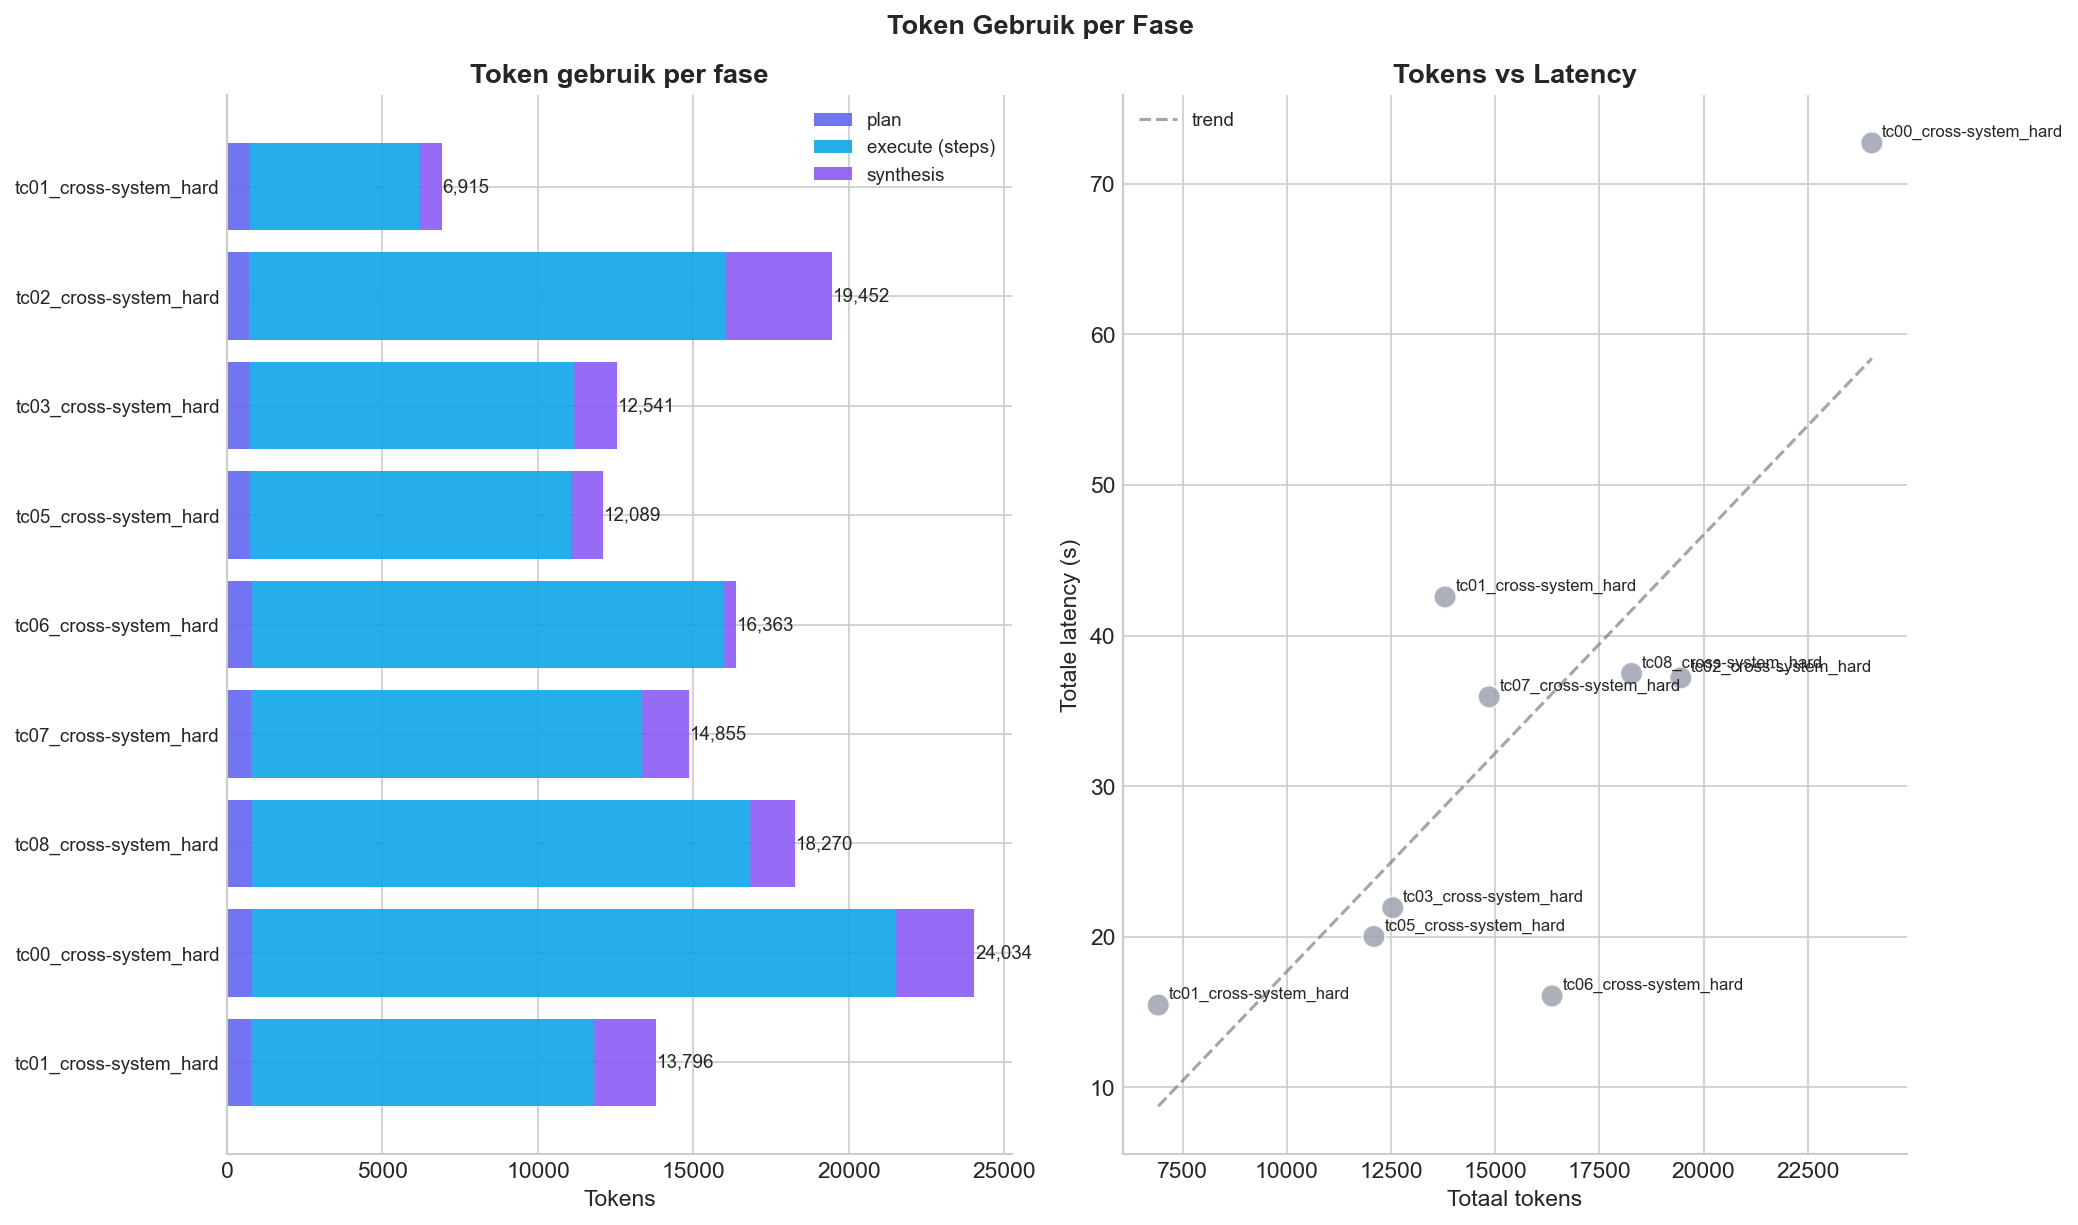

In [16]:
if df.empty:
    print('Geen data.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(df) * 0.7 + 2)))

    labels = [r['run_name'] for _, r in df.iterrows()]
    x      = np.arange(len(df))

    plan_tok    = df['plan_tokens'].values.astype(float)
    execute_tok = df['execute_tokens'].values.astype(float)
    synth_tok   = df['synth_tokens'].values.astype(float)
    total_tok   = plan_tok + execute_tok + synth_tok

    # -- Stacked tokens --
    ax = axes[0]
    ax.barh(x, plan_tok,    color=PHASE_COLORS['plan'],      label='plan',     alpha=0.9)
    ax.barh(x, execute_tok, left=plan_tok,
            color='#0ea5e9', label='execute (steps)', alpha=0.9)
    ax.barh(x, synth_tok,   left=plan_tok + execute_tok,
            color=PHASE_COLORS['synthesis'], label='synthesis', alpha=0.9)

    for i, tot in enumerate(total_tok):
        ax.text(tot + 20, i, f'{int(tot):,}', va='center', fontsize=9)

    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Tokens')
    ax.set_title('Token gebruik per fase', fontweight='bold')
    ax.legend(fontsize=9)

    # -- Tokens vs latency scatter: zijn tokendure requests ook langzamer? --
    ax = axes[1]
    sc = ax.scatter(
        total_tok, df['total_lat'],
        c=[AGENT_COLORS.get(c, '#9ca3af') for c in df.get('category', pd.Series(['unknown']*len(df)))],
        s=120, alpha=0.85, edgecolors='white', zorder=3,
    )
    for _, r in df.iterrows():
        ax.annotate(r['run_name'], (r['execute_tokens'] + r['plan_tokens'] + r['synth_tokens'],
                                    r['total_lat']),
                    fontsize=8, xytext=(5, 3), textcoords='offset points')

    # trendlijn
    if len(df) > 2:
        z = np.polyfit(total_tok, df['total_lat'].values, 1)
        p = np.poly1d(z)
        xs = np.linspace(total_tok.min(), total_tok.max(), 50)
        ax.plot(xs, p(xs), '--', color='gray', lw=1.5, alpha=0.7, label='trend')
        ax.legend(fontsize=9)

    ax.set_xlabel('Totaal tokens')
    ax.set_ylabel('Totale latency (s)')
    ax.set_title('Tokens vs Latency', fontweight='bold')

    plt.suptitle('Token Gebruik per Fase', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_tokens_per_phase.png', bbox_inches='tight')
    plt.show()

## 4. LLM-turns & tool calls per stap
Per request: hoeveel LLM-iteraties en welke tools werden aangeroepen per stap.

21 stappen totaal


,run_name,step_id,agent,latency_s,llm_turns,n_tool_calls,tool_calls
0,tc01_cross-system_hard,1,salesforce,21.149,0,0,
1,tc01_cross-system_hard,2,graph,15.756,0,0,
2,tc00_cross-system_hard,1,graph,42.726,0,0,
3,tc00_cross-system_hard,2,salesforce,8.555,0,0,
4,tc00_cross-system_hard,3,smartsales,9.993,0,0,
5,tc08_cross-system_hard,1,salesforce,5.977,0,0,
6,tc08_cross-system_hard,2,smartsales,6.063,0,0,
7,tc08_cross-system_hard,3,graph,5.440,0,0,
8,tc07_cross-system_hard,1,graph,17.795,0,0,
9,tc07_cross-system_hard,2,salesforce,9.878,0,0,


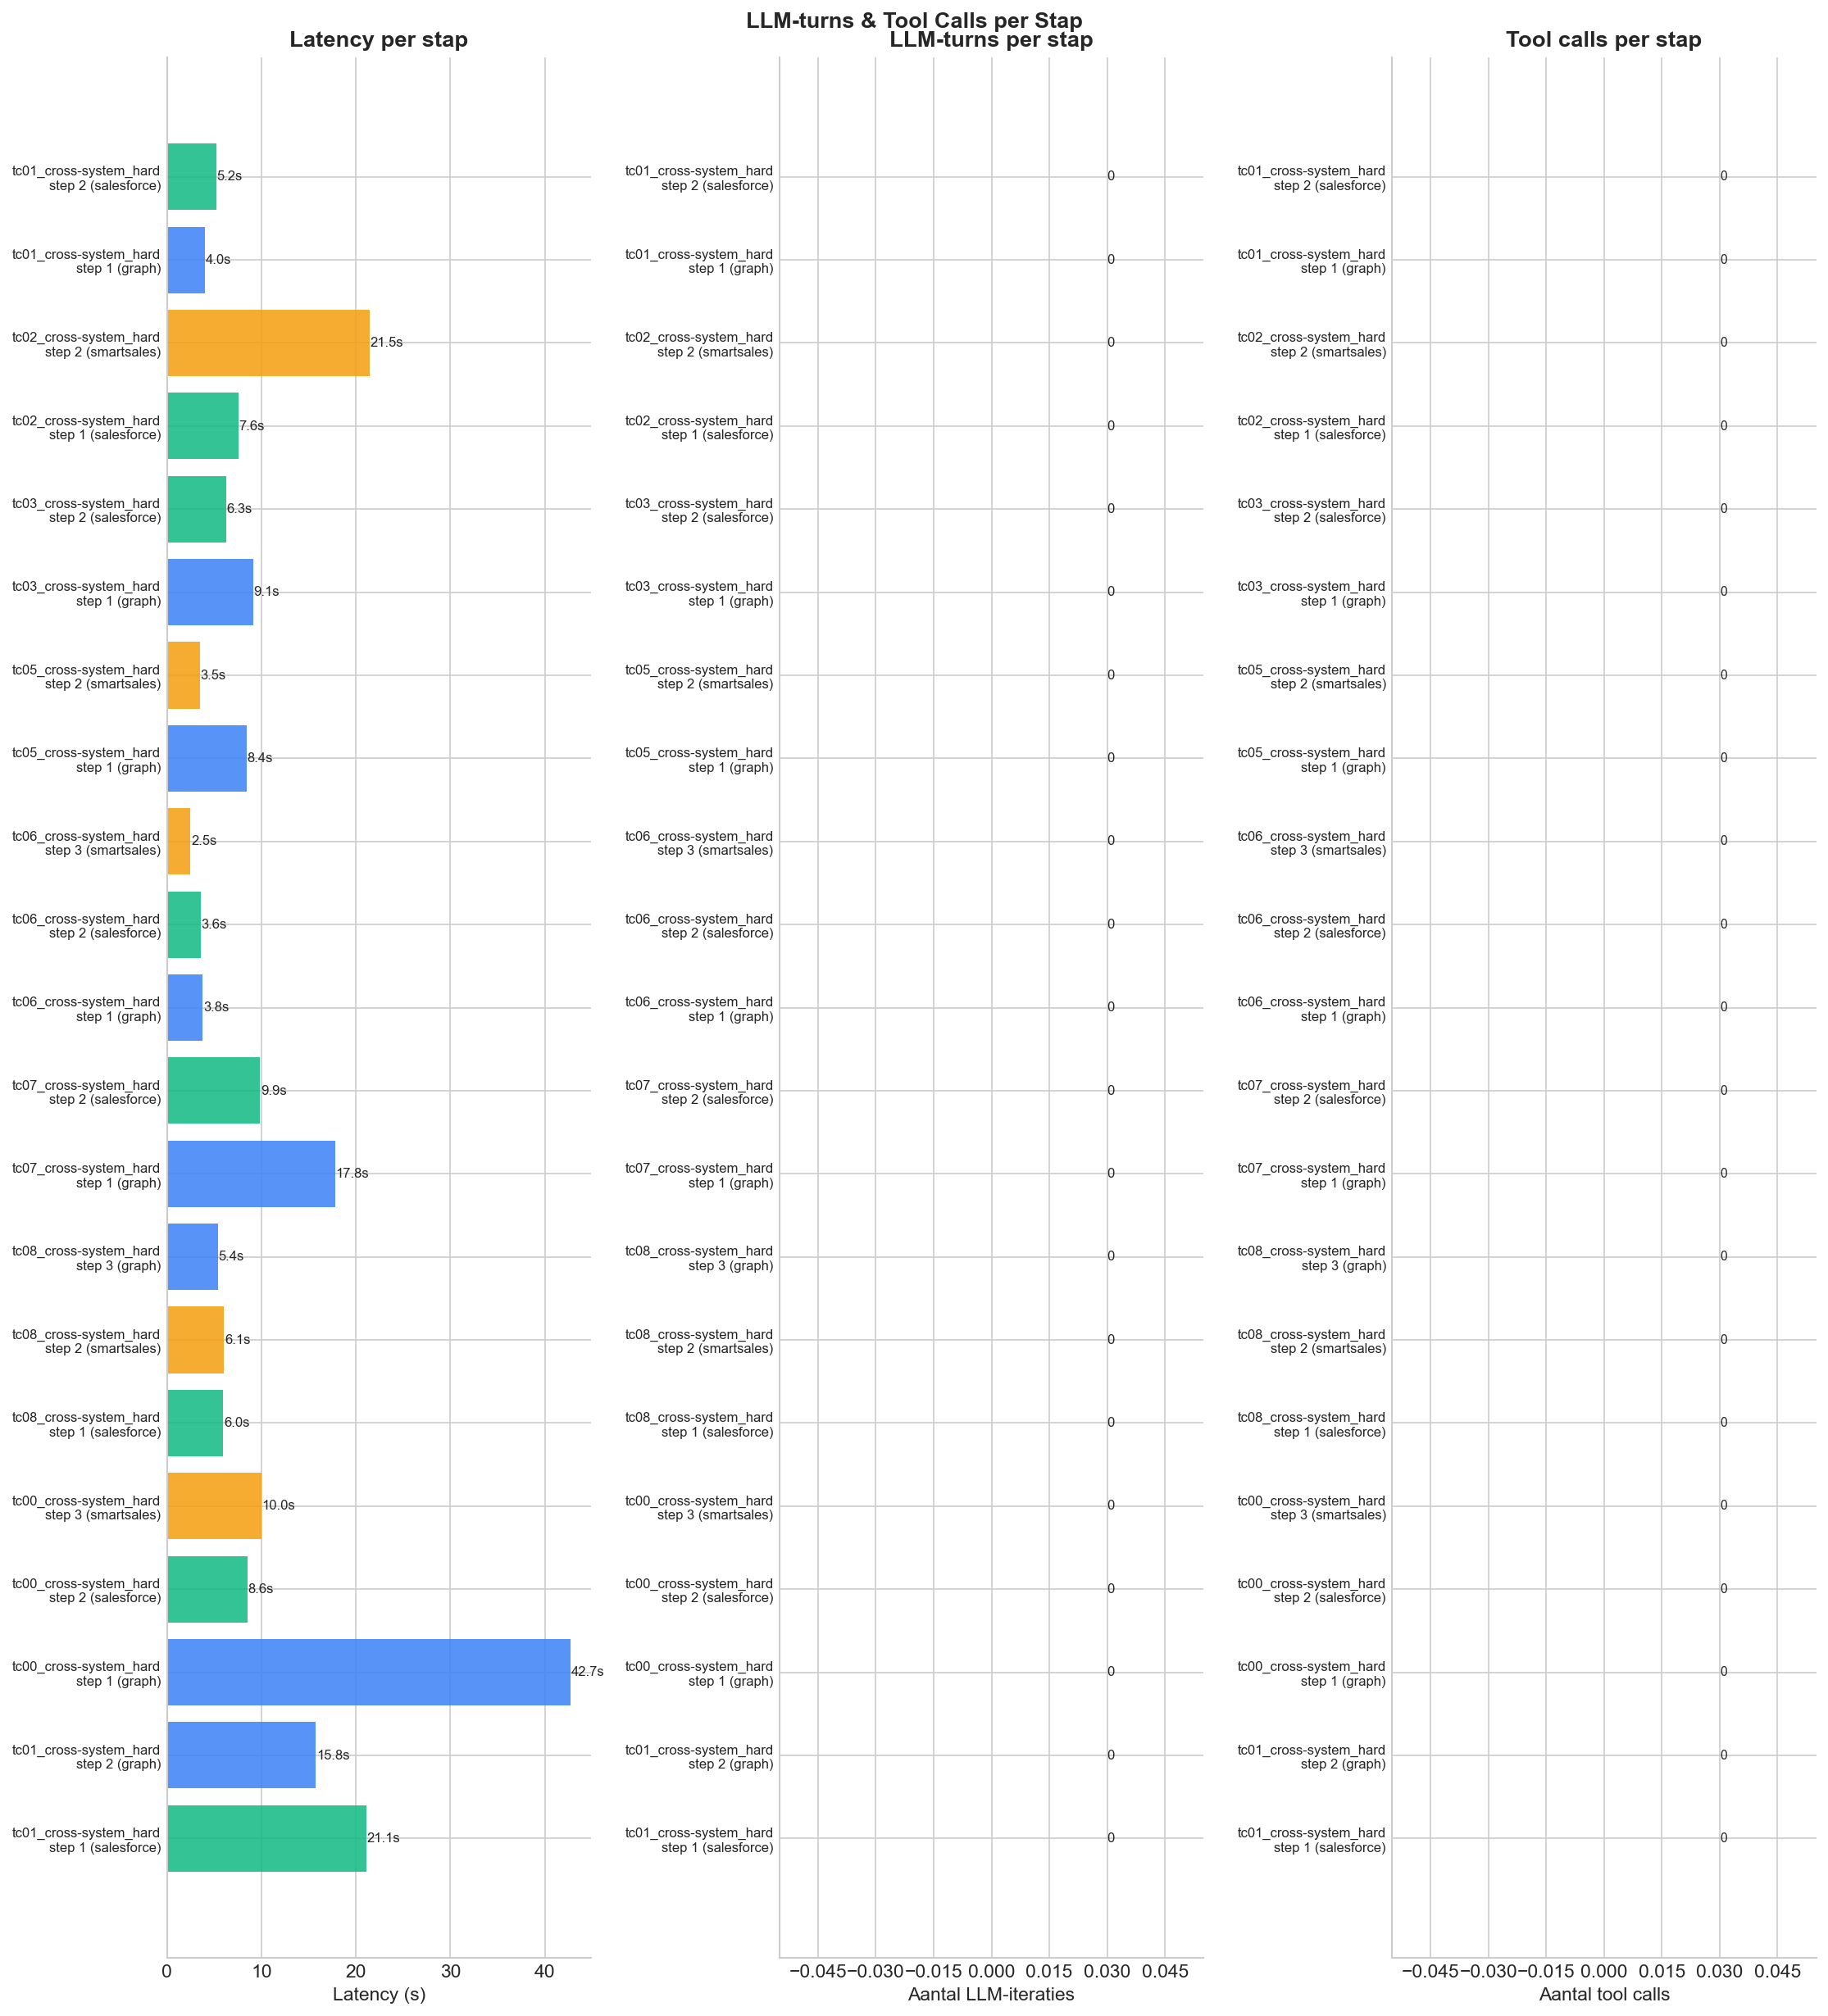

In [ ]:
# Explodeer segmenten naar platte tabel voor stap-analyse
step_rows = []
for _, row in df.iterrows():
    for seg in row['segments']:
        if 'step_id' not in seg:
            continue
        step_rows.append({
            'run_name':    row['run_name'],
            'step_id':     seg['step_id'],
            'agent':       seg.get('agent', 'unknown'),
            'latency_s':   seg['end'] - seg['start'],
            'llm_turns':   seg['llm_turns'],
            'n_tool_calls': seg.get('n_tool_calls', 0),
            'tool_calls':  ', '.join(seg.get('tool_calls', [])),
        })

sdf = pd.DataFrame(step_rows)

if sdf.empty:
    print('Geen stap-data beschikbaar.')
else:
    print(f'{len(sdf)} stappen totaal')
    display(sdf)

    fig, axes = plt.subplots(1, 3, figsize=(15, max(4, len(sdf) * 0.7 + 2)))

    step_labels = [f"{r['run_name']}\nstep {r['step_id']} ({r['agent']})" for _, r in sdf.iterrows()]
    colors      = [AGENT_COLORS.get(a, '#9ca3af') for a in sdf['agent']]
    x = np.arange(len(sdf))

    # Latency per stap
    ax = axes[0]
    bars = ax.barh(x, sdf['latency_s'], color=colors, alpha=0.85)
    for bar, v in zip(bars, sdf['latency_s']):
        ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}s', va='center', fontsize=8)
    ax.set_yticks(x)
    ax.set_yticklabels(step_labels, fontsize=8)
    ax.set_xlabel('Latency (s)')
    ax.set_title('Latency per stap', fontweight='bold')

    # LLM-turns per stap
    ax = axes[1]
    bars = ax.barh(x, sdf['llm_turns'], color=colors, alpha=0.85)
    for bar, v in zip(bars, sdf['llm_turns']):
        ax.text(v + 0.03, bar.get_y() + bar.get_height()/2,
                str(int(v)), va='center', fontsize=8)
    ax.set_yticks(x)
    ax.set_yticklabels(step_labels, fontsize=8)
    ax.set_xlabel('Aantal LLM-iteraties')
    ax.set_title('LLM-turns per stap', fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Tool calls per stap
    ax = axes[2]
    bars = ax.barh(x, sdf['n_tool_calls'], color=colors, alpha=0.85)
    for bar, (v, tc) in zip(bars, zip(sdf['n_tool_calls'], sdf['tool_calls'])):
        label = f"{int(v)}  {tc}" if tc else str(int(v))
        ax.text(v + 0.03, bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=7.5)
    ax.set_yticks(x)
    ax.set_yticklabels(step_labels, fontsize=8)
    ax.set_xlabel('Aantal tool calls')
    ax.set_title('Tool calls per stap', fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.suptitle('LLM-turns & Tool Calls per Stap', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_steps_detail.png', bbox_inches='tight')
    plt.show()

## 5. Bottleneck analyse — welke fase domineert?
Scatter + pie tonen welke fase de meeste tijd opslokt.

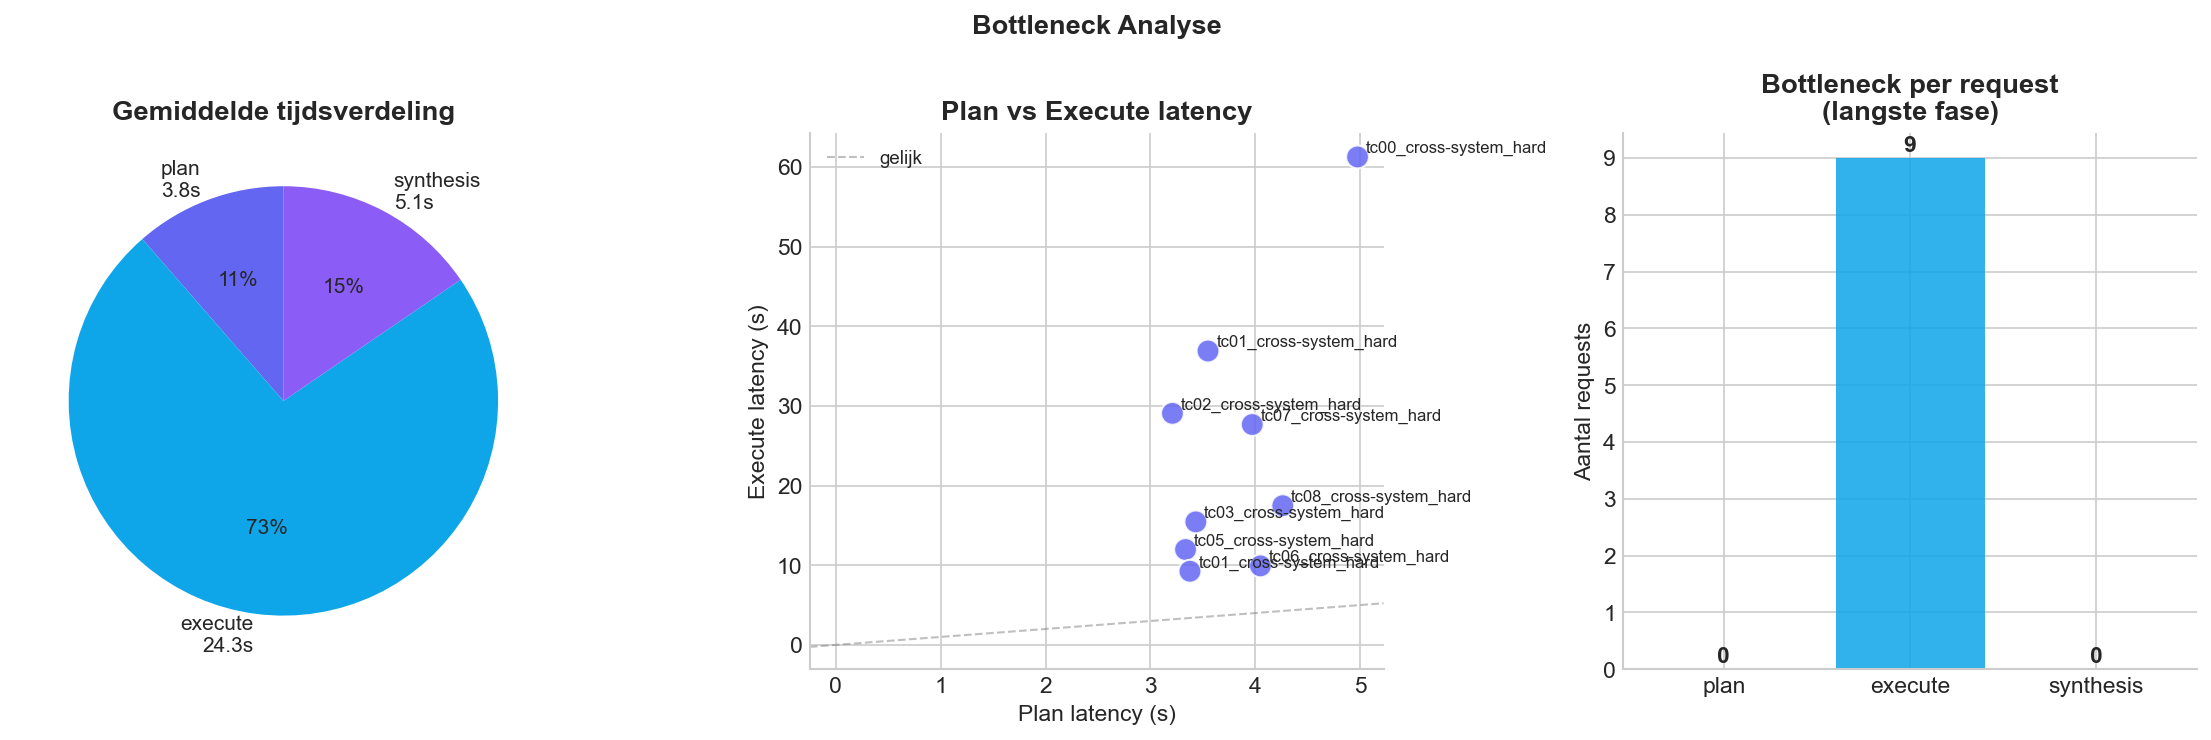


── Bottleneck samenvatting ──
  execute     : bottleneck in 9/9 requests (100%)


In [18]:
if df.empty:
    print('Geen data.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    plan_v    = df['plan_lat'].values
    execute_v = df['execute_lat'].values
    synth_v   = df['synth_lat'].values
    total_v   = plan_v + execute_v + synth_v

    # -- Pie: gemiddelde tijdsverdeling --
    ax = axes[0]
    means = [plan_v.mean(), execute_v.mean(), synth_v.mean()]
    ax.pie(
        means,
        labels=[f'plan\n{means[0]:.1f}s', f'execute\n{means[1]:.1f}s', f'synthesis\n{means[2]:.1f}s'],
        colors=[PHASE_COLORS['plan'], '#0ea5e9', PHASE_COLORS['synthesis']],
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10},
    )
    ax.set_title('Gemiddelde tijdsverdeling', fontweight='bold')

    # -- Scatter: plan vs execute latency --
    ax = axes[1]
    ax.scatter(plan_v, execute_v,
               c=[PHASE_COLORS['plan']] * len(df), s=120, alpha=0.85,
               edgecolors='white', zorder=3)
    for _, r in df.iterrows():
        ax.annotate(r['run_name'], (r['plan_lat'], r['execute_lat']),
                    fontsize=8, xytext=(4, 2), textcoords='offset points')
    ax.set_xlabel('Plan latency (s)')
    ax.set_ylabel('Execute latency (s)')
    ax.set_title('Plan vs Execute latency', fontweight='bold')
    ax.axline((0, 0), slope=1, ls='--', color='gray', lw=1, alpha=0.5, label='gelijk')
    ax.legend(fontsize=9)

    # -- Bar: fase die het langste duurt per request (bottleneck identificatie) --
    ax = axes[2]
    # Welke fase is de bottleneck per request?
    bottlenecks = []
    for p, e, s in zip(plan_v, execute_v, synth_v):
        worst = max([(p, 'plan'), (e, 'execute'), (s, 'synthesis')])
        bottlenecks.append(worst[1])

    from collections import Counter
    counts = Counter(bottlenecks)
    phases = ['plan', 'execute', 'synthesis']
    vals   = [counts.get(ph, 0) for ph in phases]
    colors_bn = [PHASE_COLORS['plan'], '#0ea5e9', PHASE_COLORS['synthesis']]
    bars = ax.bar(phases, vals, color=colors_bn, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Aantal requests')
    ax.set_title('Bottleneck per request\n(langste fase)', fontweight='bold')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.suptitle('Bottleneck Analyse', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_bottleneck.png', bbox_inches='tight')
    plt.show()

    print('\n── Bottleneck samenvatting ──')
    for ph, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        pct = cnt / len(df) * 100
        print(f'  {ph:<12}: bottleneck in {cnt}/{len(df)} requests ({pct:.0f}%)')

## 6. Per-request detail — tokens + latency per fase naast elkaar
Gecombineerde view: voor elke request is zowel de latency als de tokens per fase zichtbaar.

## 7. Execute deep-dive — wat kost tijd binnen een stap?

Per stap weten we: totale latency, aantal LLM-turns, aantal tool calls, tool namen.  
De flow binnen een stap is altijd: **LLM → tool → LLM → tool → ... → LLM (antwoord)**.  
Hieronder een geschatte tijdopsplitsing (proportioneel) + tool-frequentieanalyse.

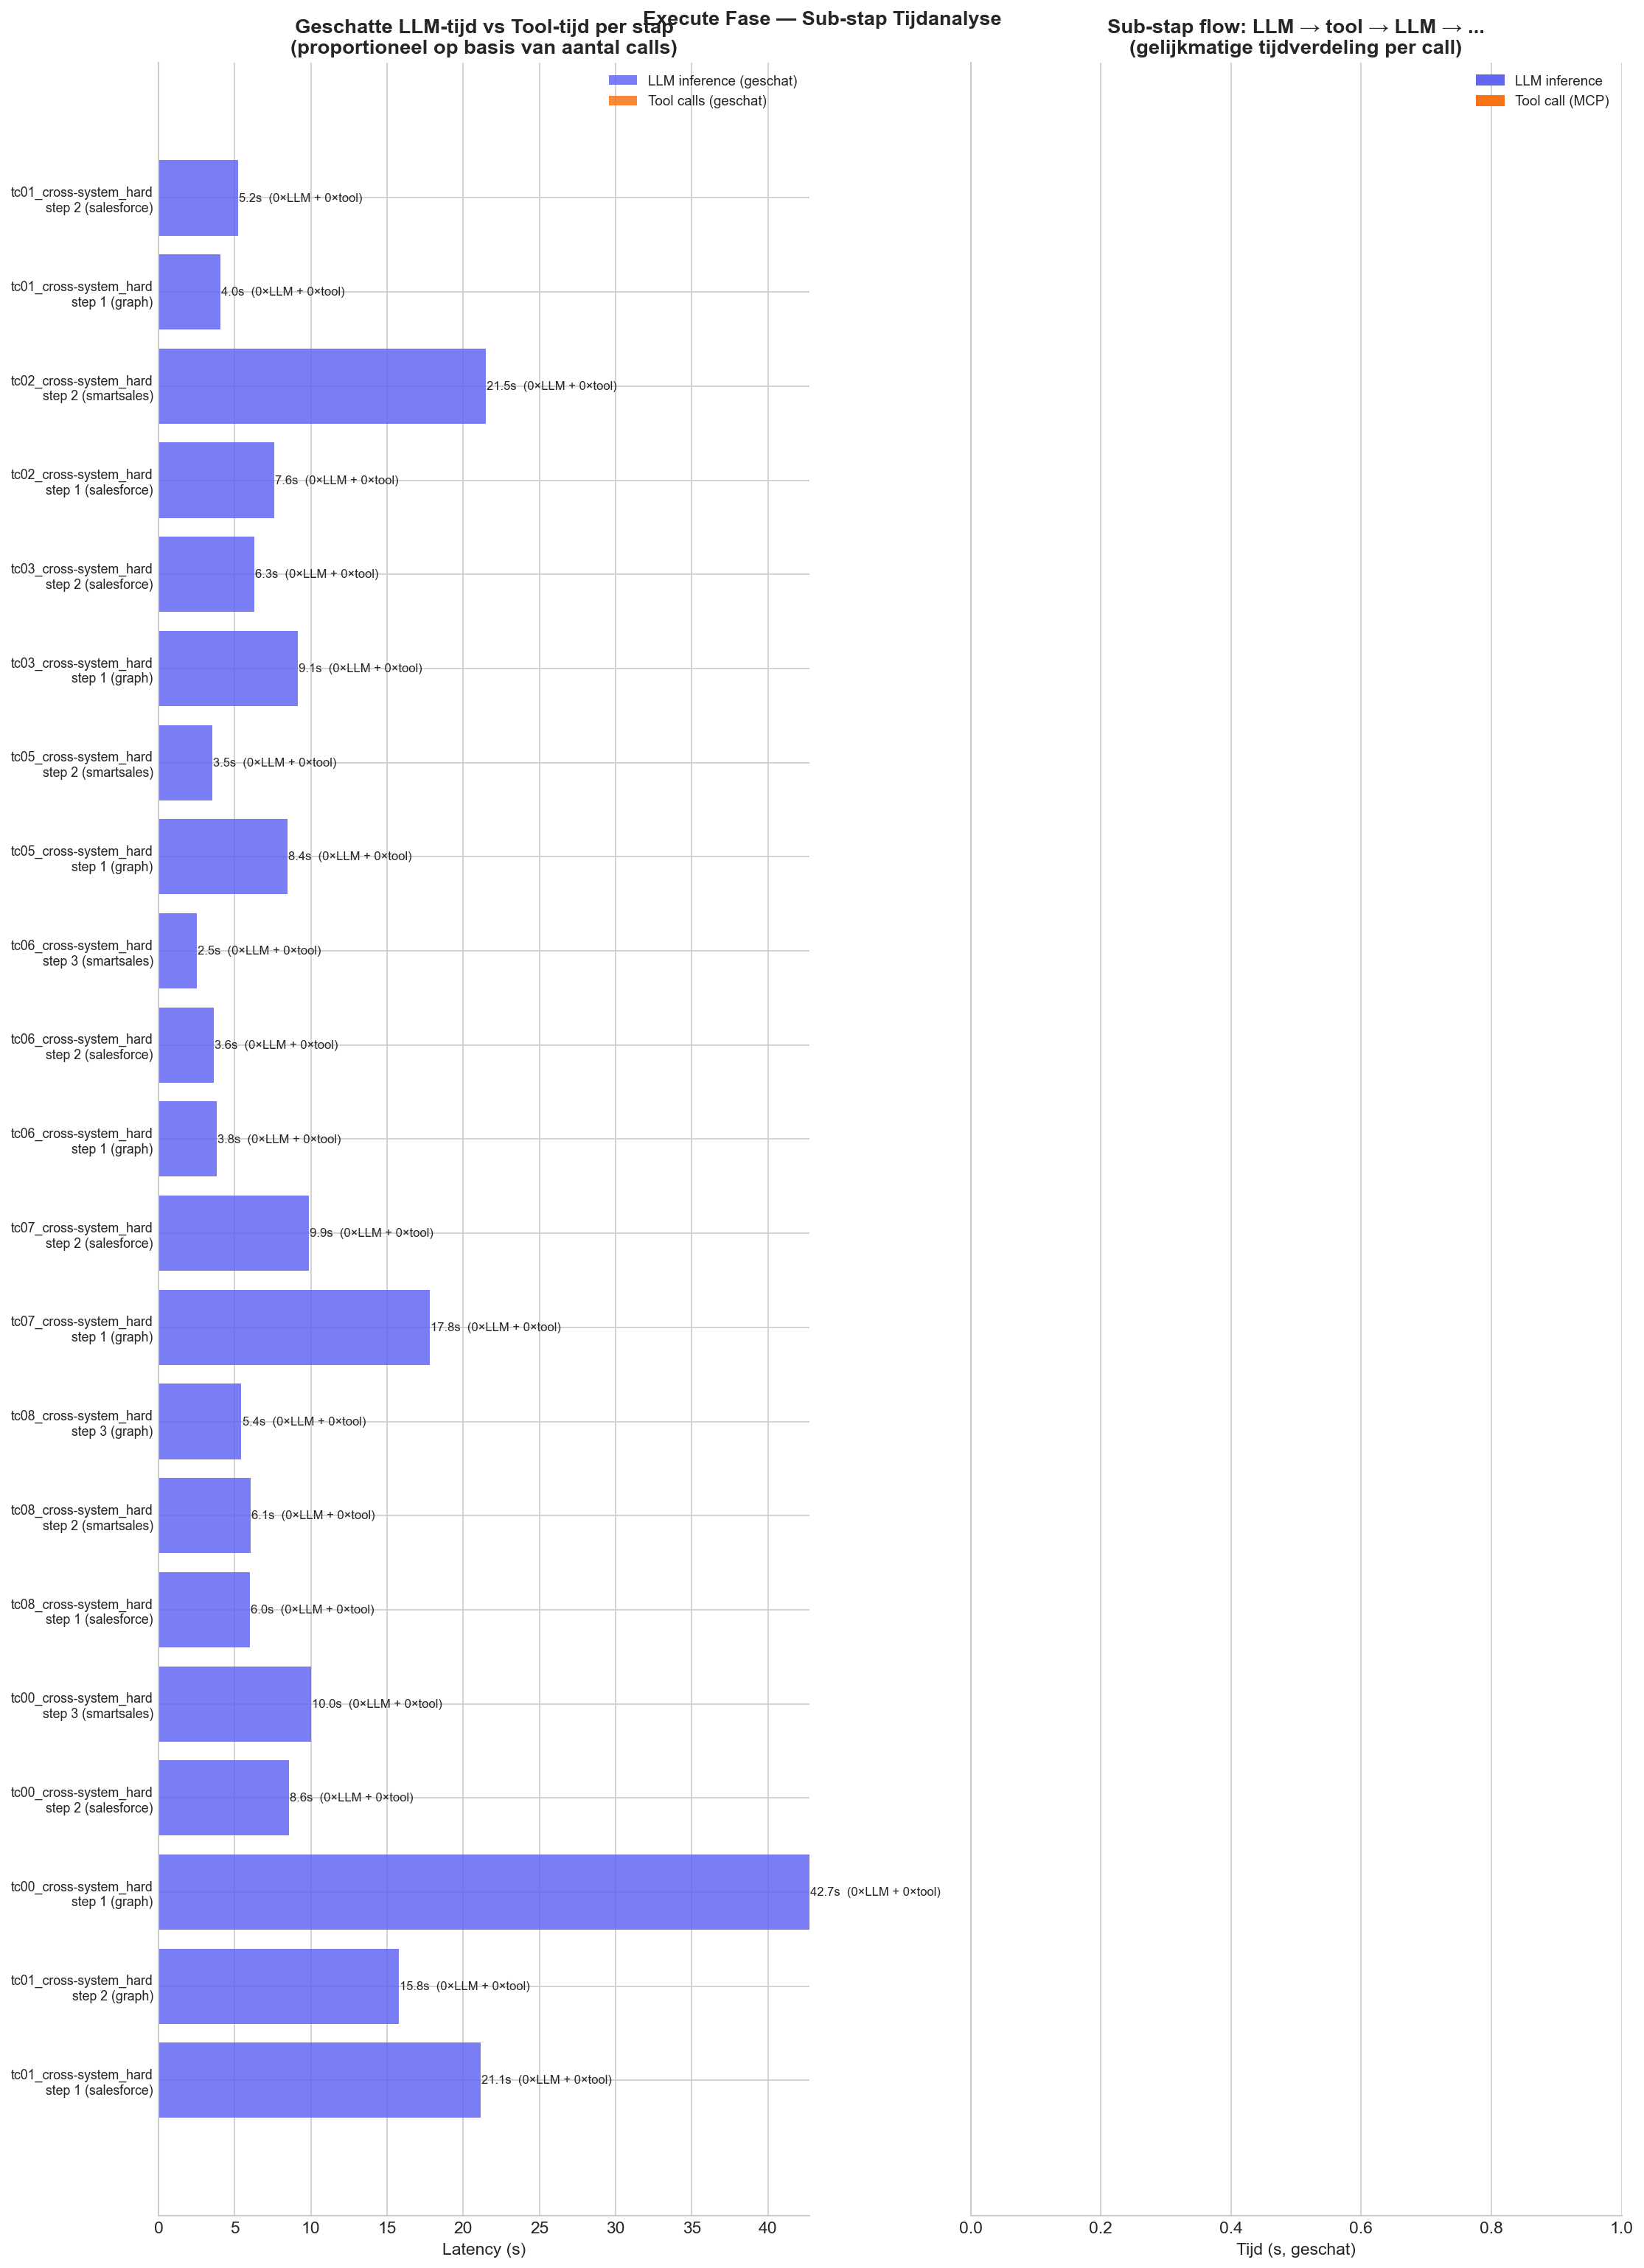

In [19]:
if 'sdf' not in dir() or sdf.empty:
    print('Run cel 4 eerst (LLM-turns & tool calls).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(sdf) * 0.9 + 2)))

    # ── Links: geschatte LLM-tijd vs tool-tijd per stap ───────────────────────
    # Proportionele schatting: totale latency verdeeld over (llm_turns + n_tool_calls)
    # LLM-blokken = llm_turns aandelen, tool-blokken = n_tool_calls aandelen
    ax = axes[0]
    step_labels = [f"{r['run_name']}\nstep {r['step_id']} ({r['agent']})" for _, r in sdf.iterrows()]
    x = np.arange(len(sdf))

    llm_est  = []
    tool_est = []
    for _, r in sdf.iterrows():
        total_calls = r['llm_turns'] + r['n_tool_calls']
        if total_calls > 0:
            unit = r['latency_s'] / total_calls
            llm_est.append(unit * r['llm_turns'])
            tool_est.append(unit * r['n_tool_calls'])
        else:
            llm_est.append(r['latency_s'])
            tool_est.append(0)

    b1 = ax.barh(x, llm_est,  color='#6366f1', alpha=0.85, label='LLM inference (geschat)')
    b2 = ax.barh(x, tool_est, left=llm_est, color='#f97316', alpha=0.85, label='Tool calls (geschat)')

    for i, (ll, tl, row) in enumerate(zip(llm_est, tool_est, sdf.itertuples())):
        total = ll + tl
        ax.text(total + 0.05, i,
                f'{total:.1f}s  ({row.llm_turns}×LLM + {row.n_tool_calls}×tool)',
                va='center', fontsize=8)

    ax.set_yticks(x)
    ax.set_yticklabels(step_labels, fontsize=8.5)
    ax.set_xlabel('Latency (s)')
    ax.set_title('Geschatte LLM-tijd vs Tool-tijd per stap\n(proportioneel op basis van aantal calls)',
                 fontweight='bold')
    ax.legend(fontsize=9)

    # ── Rechts: sub-stap mini-waterfall (LLM→tool→LLM→...) ───────────────────
    # Toon de interleaved flow als blokjes op een tijdlijn
    ax = axes[1]
    colors_flow = {'llm': '#6366f1', 'tool': '#f97316'}
    y_pos = []
    y_lbls = []

    for i, (_, r) in enumerate(sdf.iterrows()):
        total_calls = r['llm_turns'] + r['n_tool_calls']
        if total_calls == 0:
            continue
        unit = r['latency_s'] / total_calls

        # Reconstrueer de volgorde: LLM, tool, LLM, tool, ..., LLM
        tool_names = r['tool_calls'].split(', ') if r['tool_calls'] else []
        sequence = []
        for turn in range(int(r['llm_turns'])):
            sequence.append(('llm', f'LLM turn {turn+1}'))
            if turn < len(tool_names):
                sequence.append(('tool', tool_names[turn]))

        t = 0
        for call_type, call_label in sequence:
            ax.barh(i, unit, left=t, height=0.5,
                    color=colors_flow[call_type], alpha=0.85, edgecolor='white', linewidth=0.5)
            if unit > 0.3:
                ax.text(t + unit / 2, i, call_label,
                        ha='center', va='center', fontsize=6.5,
                        color='white', fontweight='bold')
            t += unit

        y_pos.append(i)
        y_lbls.append(f"{r['run_name']} step {r['step_id']}")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_lbls, fontsize=8.5)
    ax.set_xlabel('Tijd (s, geschat)')
    ax.set_title('Sub-stap flow: LLM → tool → LLM → ...\n(gelijkmatige tijdverdeling per call)',
                 fontweight='bold')

    legend_patches = [
        mpatches.Patch(color='#6366f1', label='LLM inference'),
        mpatches.Patch(color='#f97316', label='Tool call (MCP)'),
    ]
    ax.legend(handles=legend_patches, fontsize=9)

    plt.suptitle('Execute Fase — Sub-stap Tijdanalyse', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_execute_deepdive.png', bbox_inches='tight')
    plt.show()


## 8. Efficiency metrics — latency per LLM-turn en per tool call

Hoeveel tijd kost **één LLM-iteratie** vs **één tool call** gemiddeld?  
Dit helpt om te beslissen: is de bottleneck het model of de externe API?

c:\Users\AALB\Desktop\mp\graph\graphxmaf\.venv\Lib\site-packages\numpy\lib\_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

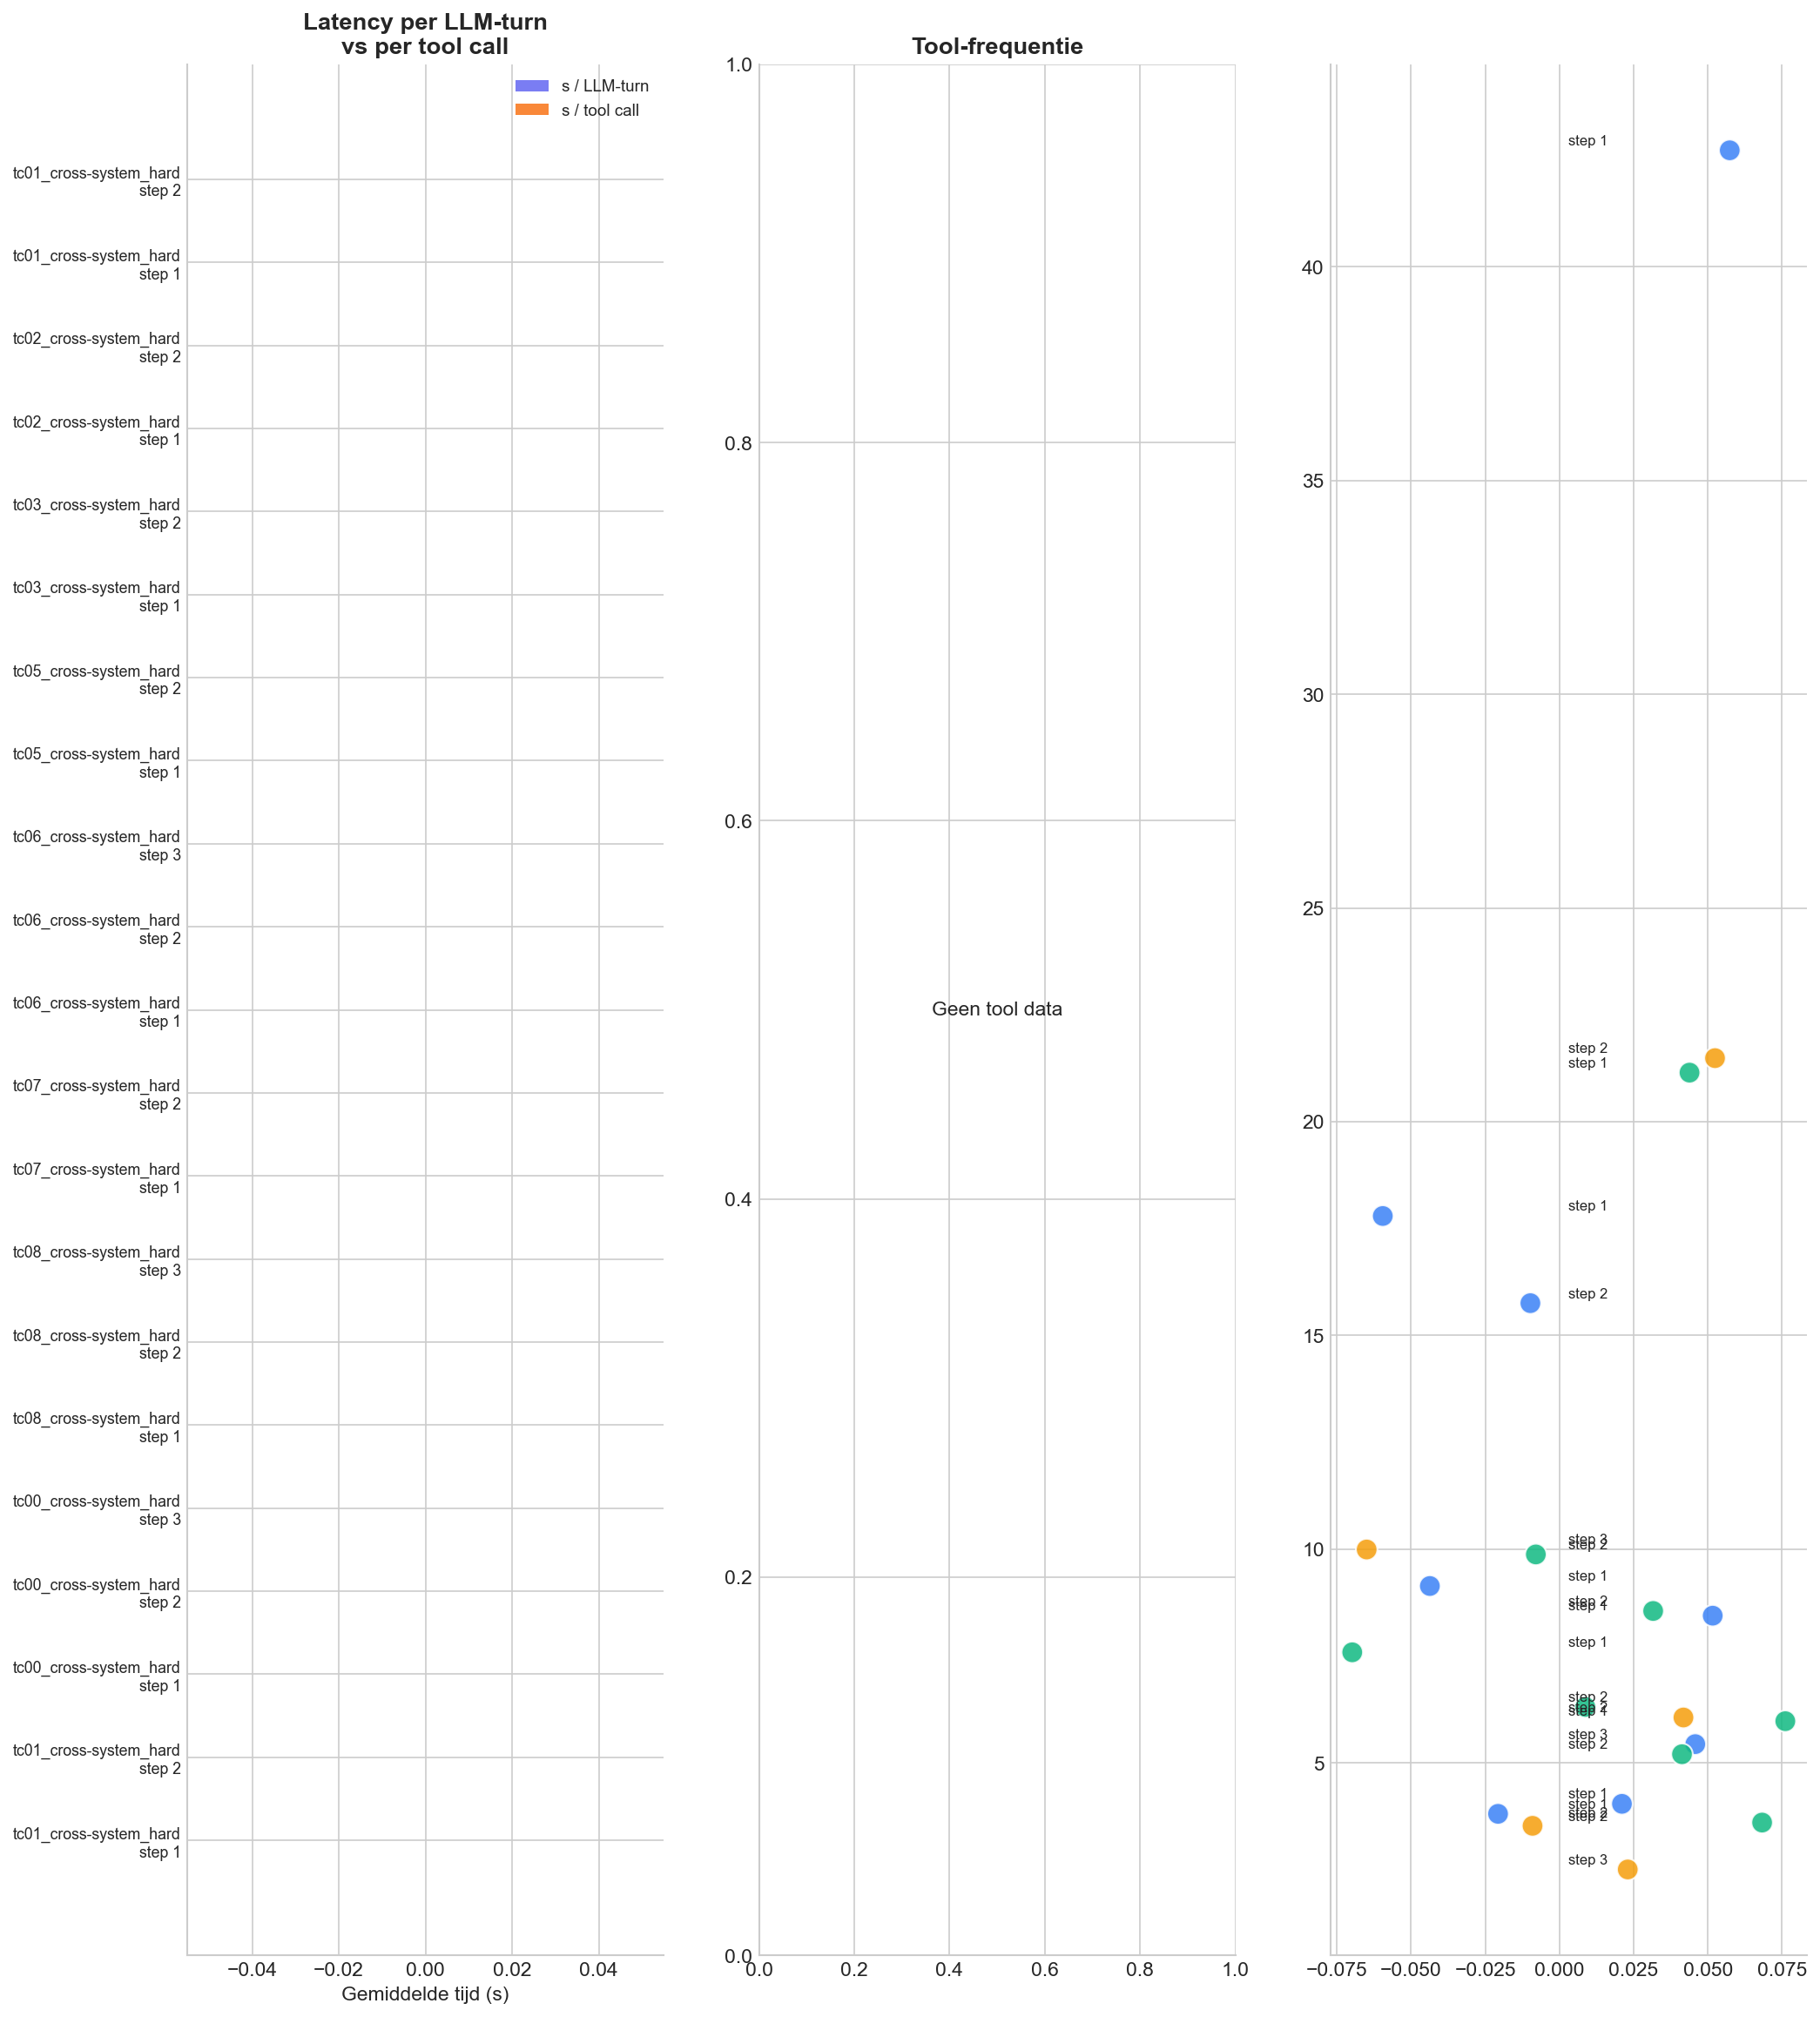

In [20]:
if 'sdf' not in dir() or sdf.empty:
    print('Run cel 4 eerst.')
else:
    from collections import Counter

    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(sdf) * 0.8 + 2)))

    # ── Links: latency per LLM-turn vs per tool call (scatter per stap) ───────
    ax = axes[0]
    lat_per_llm  = sdf['latency_s'] / sdf['llm_turns'].replace(0, np.nan)
    lat_per_tool = sdf['latency_s'] / sdf['n_tool_calls'].replace(0, np.nan)

    x = np.arange(len(sdf))
    step_labels = [f"{r['run_name']}\nstep {r['step_id']}" for _, r in sdf.iterrows()]
    colors = [AGENT_COLORS.get(a, '#9ca3af') for a in sdf['agent']]

    w = 0.35
    b1 = ax.barh(x - w/2, lat_per_llm.fillna(0),  w,
                 color='#6366f1', alpha=0.85, label='s / LLM-turn')
    b2 = ax.barh(x + w/2, lat_per_tool.fillna(0), w,
                 color='#f97316', alpha=0.85, label='s / tool call')

    for bar, v in zip(b1, lat_per_llm.fillna(0)):
        if v > 0:
            ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
                    f'{v:.1f}s', va='center', fontsize=8)
    for bar, v in zip(b2, lat_per_tool.fillna(0)):
        if v > 0:
            ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
                    f'{v:.1f}s', va='center', fontsize=8)

    ax.set_yticks(x)
    ax.set_yticklabels(step_labels, fontsize=8.5)
    ax.set_xlabel('Gemiddelde tijd (s)')
    ax.set_title('Latency per LLM-turn\nvs per tool call', fontweight='bold')
    ax.legend(fontsize=9)
    ax.axvline(lat_per_llm.mean(), ls='--', color='#6366f1', lw=1.2, alpha=0.6,
               label=f'gem LLM {lat_per_llm.mean():.1f}s')
    ax.axvline(lat_per_tool.mean(), ls='--', color='#f97316', lw=1.2, alpha=0.6,
               label=f'gem tool {lat_per_tool.mean():.1f}s')

    # ── Midden: tool-frequentie — welke tools werden het meest aangeroepen? ───
    ax = axes[1]
    all_tools = []
    for tc in sdf['tool_calls']:
        if tc:
            all_tools.extend(tc.split(', '))

    if all_tools:
        tool_counts = Counter(all_tools)
        tools_sorted = sorted(tool_counts.items(), key=lambda x: -x[1])
        t_names = [t for t, _ in tools_sorted]
        t_vals  = [v for _, v in tools_sorted]
        t_colors = plt.cm.Set2(np.linspace(0, 1, len(t_names)))

        bars = ax.barh(range(len(t_names)), t_vals, color=t_colors, alpha=0.85)
        for bar, v in zip(bars, t_vals):
            ax.text(v + 0.03, bar.get_y() + bar.get_height()/2,
                    str(v), va='center', fontsize=9, fontweight='bold')
        ax.set_yticks(range(len(t_names)))
        ax.set_yticklabels(t_names, fontsize=9)
        ax.set_xlabel('Aantal aanroepen')
        ax.set_title('Tool-frequentie\n(alle stappen samen)', fontweight='bold')
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    else:
        ax.text(0.5, 0.5, 'Geen tool data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Tool-frequentie', fontweight='bold')

    # ── Rechts: n_tool_calls vs step latency scatter (correleert meer tools = trager?) ──
    ax = axes[2]
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(sdf))
    sc = ax.scatter(
        sdf['n_tool_calls'] + jitter,
        sdf['latency_s'],
        c=colors, s=140, alpha=0.85, edgecolors='white', zorder=3,
    )
    for _, r in sdf.iterrows():
        ax.annotate(
            f"step {r['step_id']}",
            (r['n_tool_calls'], r['latency_s']),
            fontsize=8, xytext=(5, 3), textcoords='offset points',
        )

    if len(sdf) > 2:
        z = np.polyfit(sdf['n_tool_calls'], sdf['latency_s'], 1)
        p = np.poly1d(z)
        xs = np.linspace(sdf['n_tool_calls'].min(), sdf['n_tool_calls'].max(), 30)
        ax.plot(xs, p(xs), '--', color='gray', lw=1.5, alpha=0.7)

    ax.set_xlabel('Aantal tool calls per stap')
    ax.set_ylabel('Stap latency (s)')
    ax.set_title('Meer tool calls → trager?\n(tool calls vs step latency)', fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.suptitle('Efficiency Metrics — Execute Fase', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_execute_efficiency.png', bbox_inches='tight')
    plt.show()

    # ── Samenvatting ─────────────────────────────────────────────────────────
    print('\n── Execute efficiency samenvatting ──')
    print(f'  Gem. latency per LLM-turn  : {lat_per_llm.mean():.2f}s')
    print(f'  Gem. latency per tool call : {lat_per_tool.mean():.2f}s  ({"n/a" if lat_per_tool.isna().all() else ""})')
    print(f'  Totaal unieke tools        : {len(set(all_tools))}  — {list(set(all_tools))}')
    print(f'  Meest gebruikte tool       : {tool_counts.most_common(1)[0] if all_tools else "n/a"}')


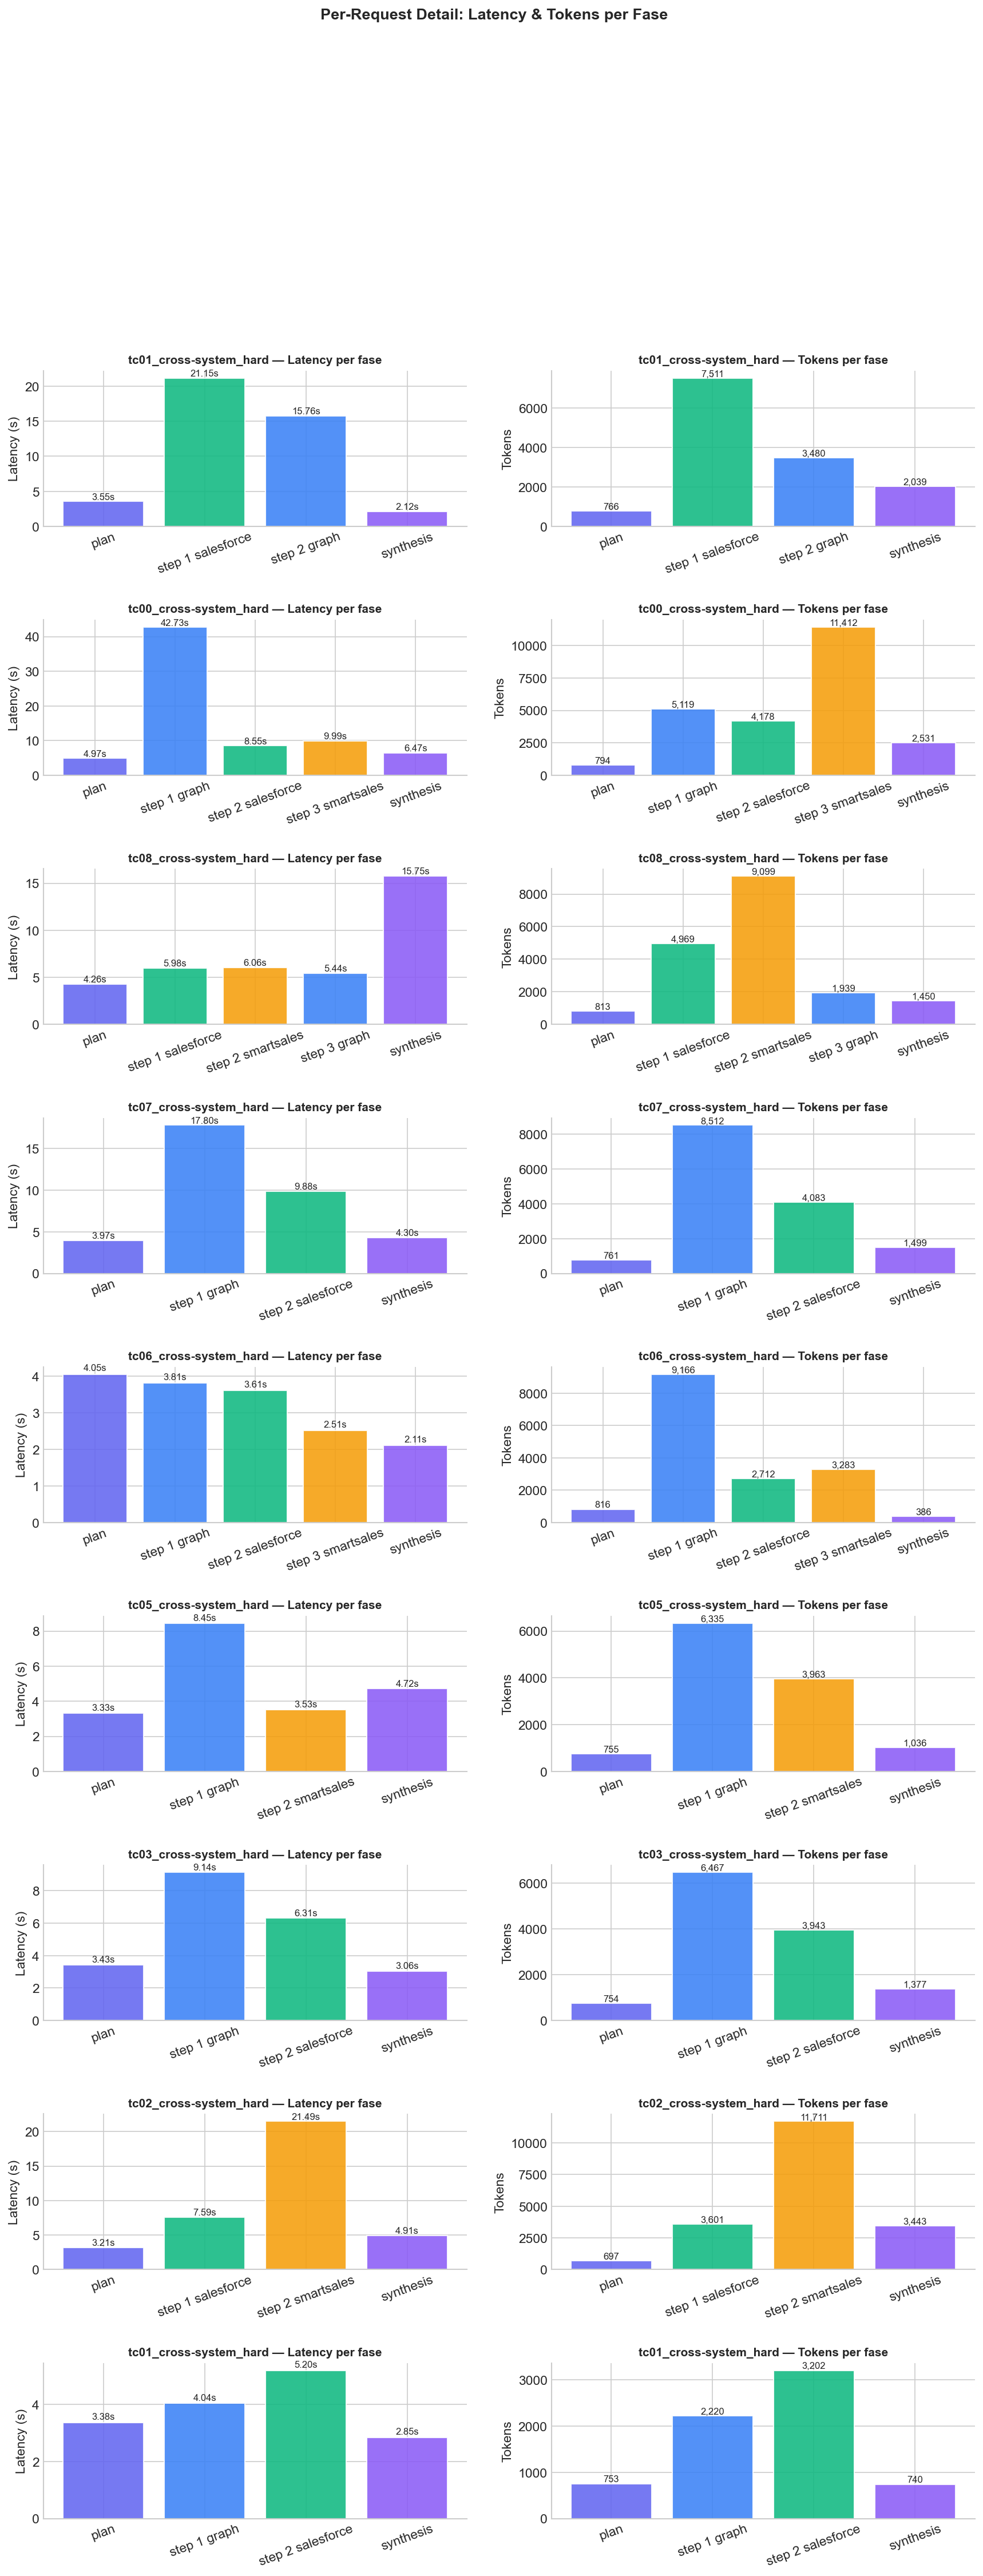

In [21]:
if df.empty:
    print('Geen data.')
else:
    n   = len(df)
    fig, axes = plt.subplots(n, 2, figsize=(14, n * 3.5 + 1),
                             gridspec_kw={'hspace': 0.6})

    if n == 1:
        axes = [axes]   # maak iterable bij 1 rij

    for i, (_, row) in enumerate(df.iterrows()):
        segs   = row['segments']
        labels = [s['label'].replace('\n', ' ') for s in segs]
        lats   = [s['end'] - s['start'] for s in segs]
        toks   = [s['tokens'].get('total_tokens', 0) for s in segs]
        colors = [s['color'] for s in segs]

        # Latency per fase
        ax = axes[i][0]
        bars = ax.bar(labels, lats, color=colors, alpha=0.88, edgecolor='white')
        for bar, v in zip(bars, lats):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
                    f'{v:.2f}s', ha='center', va='bottom', fontsize=8)
        ax.set_ylabel('Latency (s)')
        ax.set_title(f"{row['run_name']} — Latency per fase",
                     fontweight='bold', fontsize=10)
        ax.tick_params(axis='x', rotation=20)

        # Tokens per fase
        ax = axes[i][1]
        bars = ax.bar(labels, toks, color=colors, alpha=0.88, edgecolor='white')
        for bar, v in zip(bars, toks):
            if v:
                ax.text(bar.get_x() + bar.get_width()/2, v + 5,
                        f'{int(v):,}', ha='center', va='bottom', fontsize=8)
        ax.set_ylabel('Tokens')
        ax.set_title(f"{row['run_name']} — Tokens per fase",
                     fontweight='bold', fontsize=10)
        ax.tick_params(axis='x', rotation=20)

    plt.suptitle('Per-Request Detail: Latency & Tokens per Fase',
                 fontweight='bold', fontsize=13, y=1.01)
    plt.savefig('plot_per_request_detail.png', bbox_inches='tight')
    plt.show()